Logistic Regression : Multiclass Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
data = pd.read_csv("/content/IRIS.csv")
print(data)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


In [ ]:
x = data[["sepal_length","sepal_width","petal_length","petal_width"]]
y = data["species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
len(X_train)

120

In [ ]:
len(X_test)

30

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
model.score(X_test, y_test)

0.9666666666666667

In [ ]:
model.predict(data[0:5][x.columns])

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa'], dtype=object)

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[10,  0,  0],
       [ 0, 13,  0],
       [ 0,  1,  6]])

Text(95.72222222222221, 0.5, 'Truth')

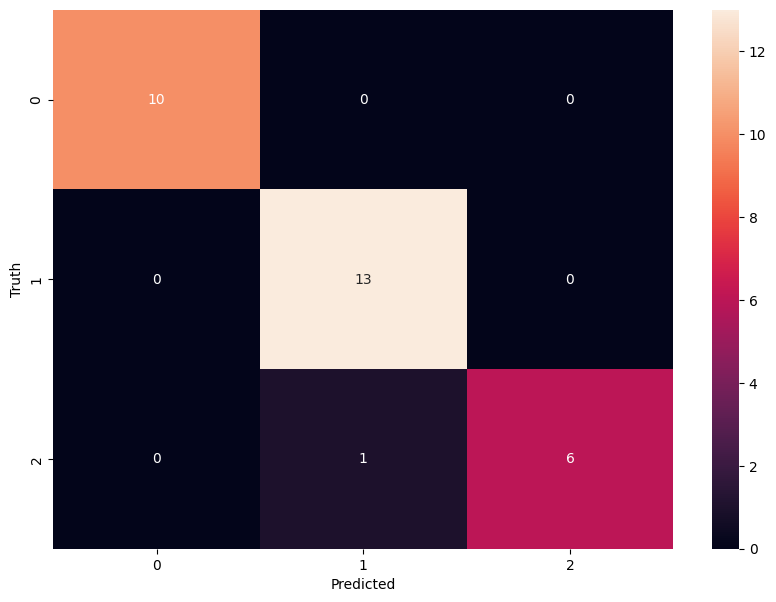

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Problem Statement

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
data = pd.read_csv("/content/Symptom2Disease.csv")
print(data)

      Unnamed: 0      label                                               text
0              0  Psoriasis  I have been experiencing a skin rash on my arm...
1              1  Psoriasis  My skin has been peeling, especially on my kne...
2              2  Psoriasis  I have been experiencing joint pain in my fing...
3              3  Psoriasis  There is a silver like dusting on my skin, esp...
4              4  Psoriasis  My nails have small dents or pits in them, and...
...          ...        ...                                                ...
1195         295   diabetes  I'm shaking and trembling all over. I've lost ...
1196         296   diabetes  Particularly in the crevices of my skin, I hav...
1197         297   diabetes  I regularly experience these intense urges and...
1198         298   diabetes  I have trouble breathing, especially outside. ...
1199         299   diabetes  I constantly sneeze and have a dry cough. My i...

[1200 rows x 3 columns]


In [ ]:
x = data[["text"]]
y = data["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
len(X_train)

960

In [ ]:
len(X_test)

240

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train['text'])
X_test_vectorized = vectorizer.transform(X_test['text'])

model.fit(X_train_vectorized, y_train)

LogisticRegression()

In [ ]:
model.score(X_test_vectorized, y_test)

0.9875

In [ ]:
new_data_text = data[0:5]['text']
new_data_vectorized = vectorizer.transform(new_data_text)
model.predict(new_data_vectorized)

array(['Psoriasis', 'Psoriasis', 'Psoriasis', 'Psoriasis', 'Psoriasis'],
      dtype=object)

In [ ]:
y_predicted = model.predict(X_test_vectorized)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 16,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  8,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 12,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 13,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0, 

Text(95.72222222222221, 0.5, 'Truth')

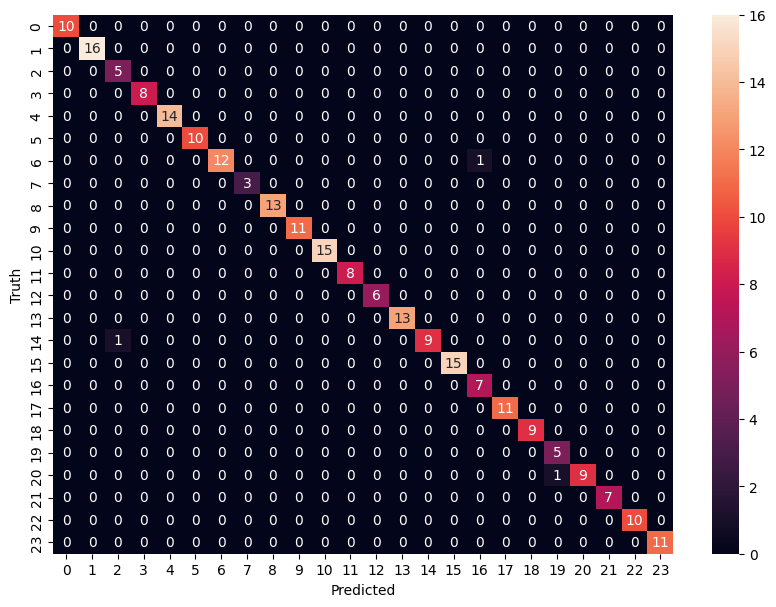

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Decision Tree

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
inputs = df.drop('Survived',axis='columns')

In [ ]:
target = df['Survived']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [ ]:
inputs['Embarked'] = inputs['Embarked'].fillna(inputs['Embarked'].mode()[0])

inputs['Sex_n'] = le_company.fit_transform(inputs['Sex'])
inputs['Embarked_n'] = le_job.fit_transform(inputs['Embarked'])

In [ ]:
inputs

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_n,Embarked_n
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,2
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,2
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,2
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,2
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,0


In [ ]:
inputs_n = inputs.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'PassengerId'], axis='columns')

In [ ]:
inputs_n

,Pclass,Age,SibSp,Parch,Fare,Sex_n,Embarked_n
0,3,22.0,1,0,7.2500,1,2
1,1,38.0,1,0,71.2833,0,0
2,3,26.0,0,0,7.9250,0,2
3,1,35.0,1,0,53.1000,0,2
4,3,35.0,0,0,8.0500,1,2
...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,2
887,1,19.0,0,0,30.0000,0,2
888,3,NaN,1,2,23.4500,0,2
889,1,26.0,0,0,30.0000,1,0


In [ ]:
target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [ ]:
model.fit(inputs_n, target)

DecisionTreeClassifier()

In [ ]:
model.score(inputs_n,target)

0.9797979797979798

Problem Statement

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

data = pd.read_csv("/content/Symptom2Disease.csv")
print(data.head())

X_text = data["text"]
y = data["label"]

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(X_text)

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Model Accuracy Score:", score)
sample = ["fever headache body pain cough"]

sample_vector = vectorizer.transform(sample)
prediction = model.predict(sample_vector)
predicted_disease = le.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...
Model Accuracy Score: 0.7916666666666666
Predicted Disease: Dengue


SVM

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
digits = load_digits()
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_accuracy = accuracy_score(y_test, linear_pred)
print("Linear Kernel Accuracy:", linear_accuracy)
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)
rbf_pred = rbf_model.predict(X_test)
rbf_accuracy = accuracy_score(y_test, rbf_pred)
print("RBF Kernel Accuracy:", rbf_accuracy)
best_accuracy = 0
best_C = None
best_gamma = None
C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]
for C in C_values:
    for gamma in gamma_values:

        tuned_model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma
        )

        tuned_model.fit(X_train, y_train)

        y_pred = tuned_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        print(f"C={C}, gamma={gamma}, Accuracy={accuracy}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_C = C
            best_gamma = gamma
print("\nBest Accuracy:", best_accuracy)
print("Best C:", best_C)
print("Best Gamma:", best_gamma)

Linear Kernel Accuracy: 0.9777777777777777
RBF Kernel Accuracy: 0.9861111111111112
C=0.1, gamma=0.001, Accuracy=0.9666666666666667
C=0.1, gamma=0.01, Accuracy=0.07777777777777778
C=0.1, gamma=0.1, Accuracy=0.07777777777777778
C=0.1, gamma=1, Accuracy=0.07777777777777778
C=1, gamma=0.001, Accuracy=0.9888888888888889
C=1, gamma=0.01, Accuracy=0.7916666666666666
C=1, gamma=0.1, Accuracy=0.07777777777777778
C=1, gamma=1, Accuracy=0.07777777777777778
C=10, gamma=0.001, Accuracy=0.9888888888888889
C=10, gamma=0.01, Accuracy=0.8138888888888889
C=10, gamma=0.1, Accuracy=0.07777777777777778
C=10, gamma=1, Accuracy=0.07777777777777778
C=100, gamma=0.001, Accuracy=0.9888888888888889
C=100, gamma=0.01, Accuracy=0.8138888888888889
C=100, gamma=0.1, Accuracy=0.07777777777777778
C=100, gamma=1, Accuracy=0.07777777777777778

Best Accuracy: 0.9888888888888889
Best C: 1
Best Gamma: 0.001


Problem Statement

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("Symptom2Disease.csv")

X_text = data["text"]
y = data["label"]

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(X_text)

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = SVC(kernel='linear')

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_pred)

print("Linear Kernel Accuracy:", linear_accuracy)

rbf_model = SVC(kernel='rbf')

rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("RBF Kernel Accuracy:", rbf_accuracy)

best_accuracy = 0
best_C = None
best_gamma = None

C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

for C in C_values:
    for gamma in gamma_values:

        tuned_model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma
        )

        tuned_model.fit(X_train, y_train)

        y_pred = tuned_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        print(f"C={C}, gamma={gamma}, Accuracy={accuracy}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_C = C
            best_gamma = gamma

print("\nBest Accuracy:", best_accuracy)
print("Best C:", best_C)
print("Best Gamma:", best_gamma)

sample = ["fever cough headache body pain"]

sample_vector = vectorizer.transform(sample)

prediction = rbf_model.predict(sample_vector)

predicted_disease = le.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

Linear Kernel Accuracy: 0.9875
RBF Kernel Accuracy: 0.9833333333333333
C=0.1, gamma=0.001, Accuracy=0.020833333333333332
C=0.1, gamma=0.01, Accuracy=0.020833333333333332
C=0.1, gamma=0.1, Accuracy=0.020833333333333332
C=0.1, gamma=1, Accuracy=0.10416666666666667
C=1, gamma=0.001, Accuracy=0.020833333333333332
C=1, gamma=0.01, Accuracy=0.020833333333333332
C=1, gamma=0.1, Accuracy=0.775
C=1, gamma=1, Accuracy=0.9833333333333333
C=10, gamma=0.001, Accuracy=0.020833333333333332
C=10, gamma=0.01, Accuracy=0.8625
C=10, gamma=0.1, Accuracy=0.9875
C=10, gamma=1, Accuracy=0.9833333333333333
C=100, gamma=0.001, Accuracy=0.8708333333333333
C=100, gamma=0.01, Accuracy=0.9916666666666667
C=100, gamma=0.1, Accuracy=0.9875
C=100, gamma=1, Accuracy=0.9833333333333333

Best Accuracy: 0.9916666666666667
Best C: 100
Best Gamma: 0.01
Predicted Disease: Dengue


Random Forest

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model_default = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)
default_score = accuracy_score(y_test, y_pred_default)
print("Accuracy with default n_estimators=10:")
print(default_score)
best_score = 0
best_trees = 0
print("\nAccuracy for different number of trees:\n")
for n in [5, 10, 20, 50, 100, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print(f"Trees: {n} ---> Accuracy: {score}")

    if score > best_score:
        best_score = score
        best_trees = n
print("\nBest Result:")
print(f"Best Accuracy = {best_score}")
print(f"Best Number of Trees = {best_trees}")

Accuracy with default n_estimators=10:
1.0

Accuracy for different number of trees:

Trees: 5 ---> Accuracy: 0.9666666666666667
Trees: 10 ---> Accuracy: 1.0
Trees: 20 ---> Accuracy: 1.0
Trees: 50 ---> Accuracy: 1.0
Trees: 100 ---> Accuracy: 1.0
Trees: 200 ---> Accuracy: 1.0

Best Result:
Best Accuracy = 1.0
Best Number of Trees = 10


Problem Statement

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("Symptom2Disease.csv")

X_text = data["text"]
y = data["label"]

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(X_text)

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_default = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model_default.fit(X_train, y_train)

y_pred_default = model_default.predict(X_test)

default_score = accuracy_score(y_test, y_pred_default)

print("Accuracy with default n_estimators=10:")
print(default_score)

best_score = 0
best_trees = 0

print("\nAccuracy for different number of trees:\n")

for n in [5, 10, 20, 50, 100, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print(f"Trees: {n} ---> Accuracy: {score}")

    if score > best_score:
        best_score = score
        best_trees = n

print("\nBest Result:")
print(f"Best Accuracy = {best_score}")
print(f"Best Number of Trees = {best_trees}")

sample = ["fever cough headache body pain"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

predicted_disease = le.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

Accuracy with default n_estimators=10:
0.8875

Accuracy for different number of trees:

Trees: 5 ---> Accuracy: 0.8208333333333333
Trees: 10 ---> Accuracy: 0.8875
Trees: 20 ---> Accuracy: 0.9125
Trees: 50 ---> Accuracy: 0.95
Trees: 100 ---> Accuracy: 0.9416666666666667
Trees: 200 ---> Accuracy: 0.9458333333333333

Best Result:
Best Accuracy = 0.95
Best Number of Trees = 50
Predicted Disease: Bronchial Asthma


K Means

In [22]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [23]:
df = pd.read_csv("/content/IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Text(0, 0.5, 'sepal_width')

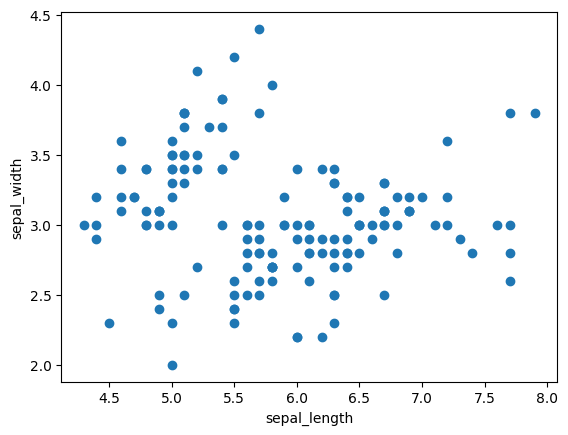

In [25]:
plt.scatter(df.sepal_length,df.sepal_width)
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

In [27]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['sepal_length','sepal_width']])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [28]:
df['cluster']=y_predicted
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [29]:
km.cluster_centers_

array([[5.00392157, 3.4       ],
       [6.82391304, 3.07826087],
       [5.8       , 2.7       ]])

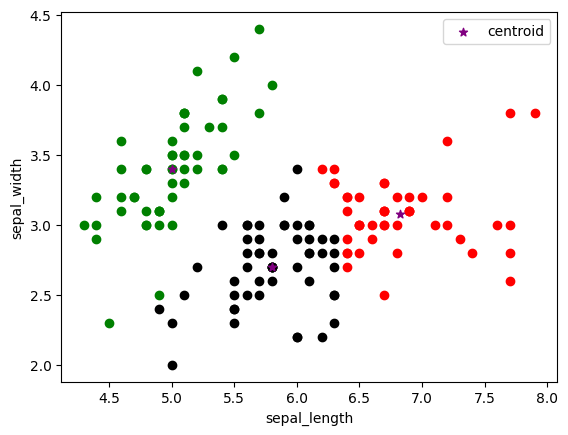

In [31]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.sepal_length,df1.sepal_width,color='green')
plt.scatter(df2.sepal_length,df2.sepal_width,color='red')
plt.scatter(df3.sepal_length,df3.sepal_width,color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()

In [33]:
scaler = MinMaxScaler()

scaler.fit(df[['sepal_length']])
df['sepal_length'] = scaler.transform(df[['sepal_length']])

scaler.fit(df[['sepal_width']])
df['sepal_width'] = scaler.transform(df[['sepal_width']])

In [34]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,0.222222,0.625000,1.4,0.2,Iris-setosa,0
1,0.166667,0.416667,1.4,0.2,Iris-setosa,0
2,0.111111,0.500000,1.3,0.2,Iris-setosa,0
3,0.083333,0.458333,1.5,0.2,Iris-setosa,0
4,0.194444,0.666667,1.4,0.2,Iris-setosa,0


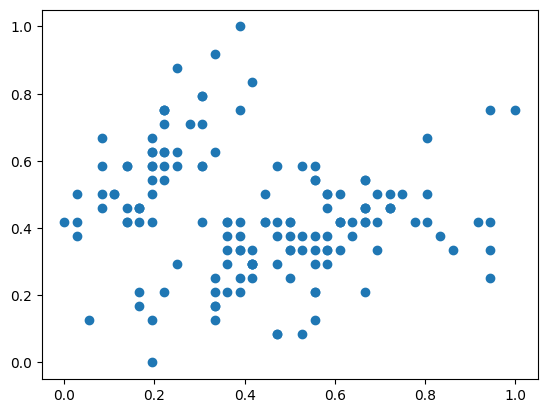

In [36]:
plt.scatter(df.sepal_length,df.sepal_width)

In [38]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['sepal_length','sepal_width']])
y_predicted

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

In [39]:
df['cluster']=y_predicted
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,0.222222,0.625000,1.4,0.2,Iris-setosa,2
1,0.166667,0.416667,1.4,0.2,Iris-setosa,2
2,0.111111,0.500000,1.3,0.2,Iris-setosa,2
3,0.083333,0.458333,1.5,0.2,Iris-setosa,2
4,0.194444,0.666667,1.4,0.2,Iris-setosa,2


In [40]:
km.cluster_centers_

array([[0.67557652, 0.44654088],
       [0.390625  , 0.26649306],
       [0.19897959, 0.60034014]])

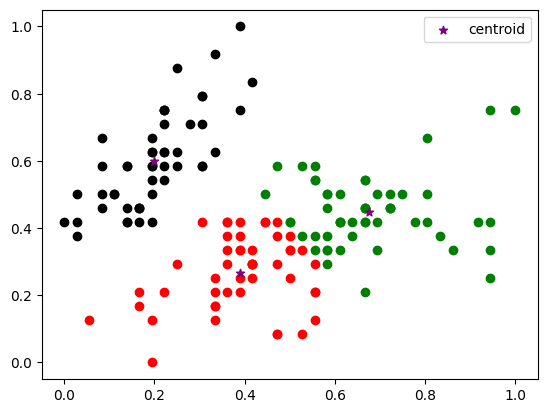

In [42]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.sepal_length,df1['sepal_width'],color='green')
plt.scatter(df2.sepal_length,df2['sepal_width'],color='red')
plt.scatter(df3.sepal_length,df3['sepal_width'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [44]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['sepal_length','sepal_width']])
    sse.append(km.inertia_)

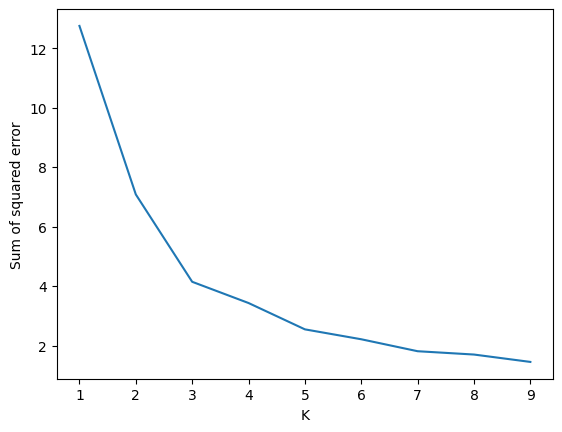

In [45]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

Problem Statement

   Feature1  Feature2
0  0.867032  0.498253
1  0.398922  0.916985
2  0.793778  0.608208
3  0.398922  0.916985
4  0.656397  0.754416


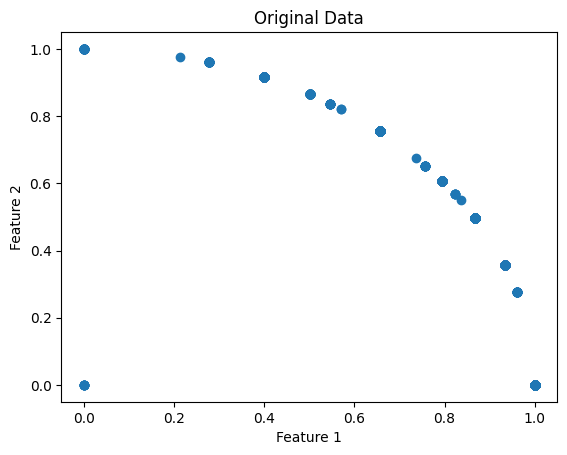

   Feature1  Feature2
0  0.867032  0.498253
1  0.398922  0.916985
2  0.793778  0.608208
3  0.398922  0.916985
4  0.656397  0.754416


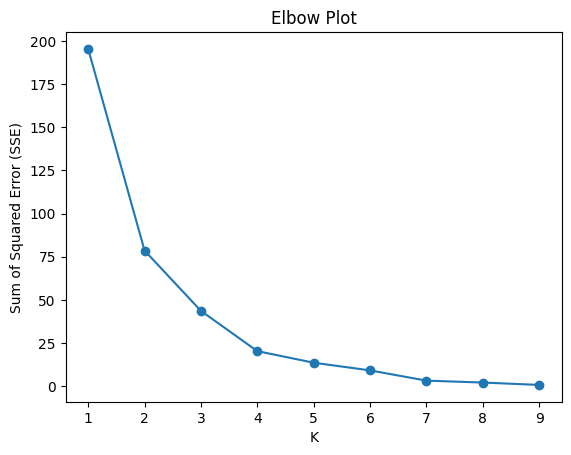

   Feature1  Feature2  cluster
0  0.867032  0.498253        0
1  0.398922  0.916985        1
2  0.793778  0.608208        2
3  0.398922  0.916985        1
4  0.656397  0.754416        2


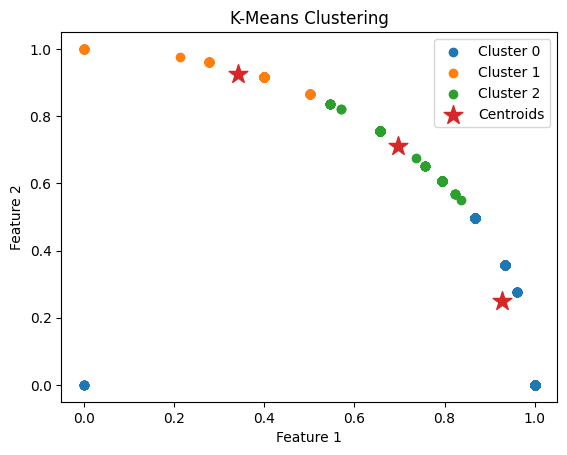

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("Symptom2Disease.csv")

vectorizer = TfidfVectorizer(max_features=2)

X = vectorizer.fit_transform(data['text'])

df = pd.DataFrame(
    X.toarray(),
    columns=['Feature1', 'Feature2']
)

print(df.head())

plt.scatter(df['Feature1'], df['Feature2'])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")

plt.show()

scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    df_scaled,
    columns=df.columns
)

print(df_scaled.head())

sse = []

k_rng = range(1, 10)

for k in k_rng:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(df_scaled)

    sse.append(km.inertia_)

plt.plot(k_rng, sse, marker='o')

plt.xlabel("K")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Elbow Plot")

plt.show()

km = KMeans(
    n_clusters=3,
    random_state=42
)

y_predicted = km.fit_predict(df_scaled)

df['cluster'] = y_predicted

print(df.head())

df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(
    df1['Feature1'],
    df1['Feature2'],
    label='Cluster 0'
)

plt.scatter(
    df2['Feature1'],
    df2['Feature2'],
    label='Cluster 1'
)

plt.scatter(
    df3['Feature1'],
    df3['Feature2'],
    label='Cluster 2'
)

plt.scatter(
    scaler.inverse_transform(km.cluster_centers_)[:,0],
    scaler.inverse_transform(km.cluster_centers_)[:,1],
    marker='*',
    s=200,
    label='Centroids'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.legend()

plt.show()

Joblib

In [47]:
import joblib

joblib.dump(model, "disease_model.pkl")

['disease_model.pkl']